### Q1.1 — Complete Data Processing Pipeline (Data wrangling with PySpark)

📋 **Objective**

Implement a robust, Spark-based data processing solution that:
1. Extracts data from ZIP archive (`business_review_submission.zip`) into `business_review_submission/`
2. Loads reviews with resilient CSV options (no schema inference, multiline/quotes/escapes handled)
3. Cleans null/empty `text` → `'no review'`
4. Parses `time` into a new `newtime` column (`yyyy-MM-dd`), handling seconds vs milliseconds safely
5. Loads business metadata and performs a Spark-to-Spark LEFT JOIN on `gmap_id`
6. Prints dataset sizes and shows a sample of cleaned data (columns: `text`, `time`, `newtime`)

🔧 **Technical Approach**
- Primary tool: PySpark (SparkSession must be initialized first)
- Session config (performance):
    - Adaptive Query Execution enabled
    - Coalesced shuffle partitions
    - Skew join handling
    - Kryo serializer
- Data sources (after extraction):
    - Reviews: `review.csv` → loaded into `reviews_cleaned`
    - Metadata: `meta-review-business.csv` → loaded into `meta_sdf`
- CSV read options (both files):
    - `header=True`, `inferSchema=False`
    - `multiline=True`, `quote="`, `escape="`
    - `ignoreLeadingWhiteSpace=False`, `ignoreTrailingWhiteSpace=False`
    - `nullValue=""`, `emptyValue=""`, `mode="PERMISSIVE"`
- Transformations:
    - Text clean: null/empty `text` → `'no review'`
    - Time parse: numeric `time` parsed to `newtime` (`yyyy-MM-dd`)
        - If `time` > 1e12 → treat as milliseconds and divide by 1000
        - Invalid/malformed → fallback to Unix epoch
- Join strategy:
    - LEFT JOIN on `gmap_id` (`reviews_cleaned` ⟶ `joined_sdf`)
    - Final dataset assigned to `reviews` (falls back to `reviews_cleaned` if join keys missing)

✅ **Expected Deliverables**
- Verified extraction and file existence checks
- Cleaned reviews with:
    - No null/empty `text`
    - Properly formatted `newtime` date
- Enriched dataset (`reviews`) after LEFT JOIN with business metadata
- Clear diagnostics:
    - Row/column counts for each stage
    - Sample preview of cleaned data (`text`, `time`, `newtime`) to validate transformations

#### Q1.1(1.1.1, 1.1.2)  DATA PROCESSING PIPELINE - Streamlined Version

In [ ]:
# ===============================================================================
# SPARK SESSION INITIALIZATION - MUST RUN FIRST!
# ===============================================================================

# Import required PySpark libraries for session management
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pathlib import Path
import zipfile
from pyspark.sql import functions as F
import shutil

print(f"⚙️ Setting up Spark session...")
print("=" * 80)

# Create and configure Spark session with optimized settings
# Key configurations for performance optimization:
#   - Adaptive Query Execution (AQE): Runtime optimization based on actual statistics
#   - Coalesce partitions: Reduce shuffle partitions to avoid tiny tasks
#   - Skew join handling: Balance work across tasks for skewed data
#   - Kryo serializer: Fast, compact serialization over Java default
spark = (
    SparkSession.builder
    .appName("Q1.BusinessReviewAnalysis")
    .config("spark.sql.adaptive.enabled", "true")                    # Enable AQE
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") # Optimize partitions
    .config("spark.sql.adaptive.skewJoin.enabled", "true")           # Handle data skew
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")  # Fast serialization
    .getOrCreate()
)

# Configure logging and confirm initialization
spark.sparkContext.setLogLevel("WARN")  # Reduce verbose logging
print(f"✅ Spark {spark.version} ready")


⚙️ Setting up Spark session...
✅ Spark 4.0.1 ready


In [2]:
# ===============================================================================
# Q1.1(1.1.1, 1.1.2)  DATA PROCESSING PIPELINE - Streamlined Version (fixed newtime)
# ===============================================================================

print("🚀 Q1.1 Data Processing Pipeline")
print("=" * 80)

# Setup paths
ws = Path.cwd()
zip_path = ws / "business_review_submission.zip"
extract_dir = ws / "business_review_submission"
review_csv = extract_dir / "review.csv"
meta_csv = extract_dir / "meta-review-business.csv"

# Extract ZIP if needed
if not all([review_csv.exists(), meta_csv.exists()]):
    extract_dir.mkdir(exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_dir)
    print("✓ ZIP extracted")
else:
    print("✓ Using existing files")

# Robust CSV read options
csv_opts = {
    "header": True,
    "inferSchema": False,
    "multiline": True,
    "escape": '"',
    "quote": '"',
    "mode": "PERMISSIVE",
    "ignoreLeadingWhiteSpace": False,
    "ignoreTrailingWhiteSpace": False,
    "nullValue": "",
    "emptyValue": ""
}

# initialize reviews and reviews_cleaned
reviews = ""
# Load reviews
reviews = spark.read.options(**csv_opts).csv(str(review_csv))

# --- FIX: accurate newtime from epoch that may be seconds, milliseconds, or scientific notation ---
# - Cast to double (handles scientific notation like "1.56633E+12")
# - If >= 1e11 -> treat as milliseconds (safe upper bound for epoch seconds)
# - If <= 0 or null -> leave as null (avoid 1970-01-01 artifacts)
# - Format as yyyy-MM-dd
ms_threshold = F.lit(1e11)  # anything above this is milliseconds

reviews_cleaned = ""
reviews_cleaned = (
    reviews
    .withColumn("text",
        F.when(F.col("text").isNull() | (F.col("text") == ""), "no review")
         .otherwise(F.col("text"))
    )
    .withColumn("time_num", F.col("time").cast("double"))
    .withColumn(
        "unix_seconds",
        F.when(F.col("time_num").isNull() | (F.col("time_num") <= 0), F.lit(None).cast("double"))
         .when(F.col("time_num") >= ms_threshold, (F.col("time_num") / F.lit(1000.0)))
         .otherwise(F.col("time_num"))
    )
    .withColumn("newtime", F.date_format(F.from_unixtime(F.col("unix_seconds")), "yyyy-MM-dd"))
    .drop("time_num", "unix_seconds")
)

# Load metadata and join with reviews if gmap_id exists in reviews columns 
meta_sdf = spark.read.options(**csv_opts).csv(str(meta_csv))

# Renames to avoid confusion after join
meta_sdf = meta_sdf.withColumnRenamed("name", "business_name")
reviews_cleaned = reviews_cleaned.withColumnRenamed("name", "reviewer_name")

# DIAGNOSTIC: Check for duplicate gmap_id in metadata to prevent row multiplication
print("🔍 Checking data quality before join...")
meta_total_rows = meta_sdf.count()
meta_unique_gmap_ids = meta_sdf.select("gmap_id").distinct().count()
print(f"📋 Metadata: {meta_total_rows:,} total rows, {meta_unique_gmap_ids:,} unique gmap_ids")

if meta_total_rows > meta_unique_gmap_ids:
    print(f"⚠️  WARNING: Found {meta_total_rows - meta_unique_gmap_ids:,} duplicate gmap_ids in metadata!")
    print("🔧 Deduplicating metadata to prevent row multiplication...")
    meta_sdf = meta_sdf.dropDuplicates(["gmap_id"])
    print(f"✅ After deduplication: {meta_sdf.count():,} rows")

# Perform the join
if "gmap_id" in reviews_cleaned.columns:
    reviews = reviews_cleaned.join(meta_sdf, on="gmap_id", how="left")
    print(f"🔗 JOIN performed: reviews_cleaned ({reviews_cleaned.count():,}) ⟵⟶ meta_sdf ({meta_sdf.count():,})")
else:
    reviews = reviews_cleaned
    print("⚠️  No gmap_id column found, skipping join")

# Display the review before join
print(f"📊 Reviews data before joining with Meta data: {reviews_cleaned.count():,} rows × {len(reviews_cleaned.columns)} cols")
print("-" * 40)

# Display final results
print(f"📊 Final result of both datasets after joining: {reviews.count():,} rows × {len(reviews.columns)} cols")
print("-" * 40)

print("\n📋 Sample cleaned data:")
term_cols = shutil.get_terminal_size(fallback=(150, 24)).columns
reserve = 40
text_width = max(30, term_cols - reserve)

reviews.select("text", "time", "newtime", "category").limit(5).show(truncate=text_width)

print("-" * 40)
print("📋 Sample data to show the data imputation with no review:")
reviews.select("text", "time", "newtime", "category").limit(10).show(truncate=text_width)



🚀 Q1.1 Data Processing Pipeline
✓ Using existing files
🔍 Checking data quality before join...
📋 Metadata: 12,774 total rows, 12,689 unique gmap_ids
⚠️  WARNING: Found 85 duplicate gmap_ids in metadata!
🔧 Deduplicating metadata to prevent row multiplication...
✅ After deduplication: 12,689 rows
🔗 JOIN performed: reviews_cleaned (521,515) ⟵⟶ meta_sdf (12,689)
📊 Reviews data before joining with Meta data: 521,515 rows × 9 cols
----------------------------------------
📊 Final result of both datasets after joining: 521,515 rows × 23 cols
----------------------------------------

📋 Sample cleaned data:
+--------------------------------------------------------------------------------------------------------------+-------------+----------+------------------------------------------------+
|                                                                                                          text|         time|   newtime|                                        category|
+---------------------

### Q1.2 Advanced Analytics: Business Review Patterns Analysis

Here we are going to build on the cleaned Spark dataset from Q1.1 to quantify review activity across businesses and uncover temporal patterns.

Objectives
- Compute review counts per business (gmap_id) at scale using Spark.
- Summarize distribution of reviews per business (min/avg/max).
- Convert an essential subset to Pandas for time-based feature engineering.
- Derive review_time (hour-of-day) and bucket into time periods: Morning, Afternoon, Evening, Night.
- Visualize hourly activity, unique businesses by time period, and top-10 most reviewed categories.

Prerequisites (from Q1.1)
- Spark DataFrame reviews with columns: gmap_id, time, text, newtime, category.
- Robust CSV ingestion and text/time cleaning already applied.

Methodology
- Q1.2.1 (Spark): groupBy gmap_id → count → stats (min/max/avg), ordered and cached.
- Q1.2.2 (Spark → Pandas): select essential columns, optional sampling for large data, convert epoch to hour, assign time_period.
- Q1.2.3 (Visualization): plot hourly distribution, unique businesses by time period, and top-10 categories by review volume.

Key Metrics (current run)
- Total reviews: 521,515
- Total unique businesses: 6,019
- Reviews per business: min 10, max 2,833, avg 86.64
- Peak hour: 04:00 with 34,137 reviews
- Most active period by unique businesses: Night

Deliverables
- Spark DataFrame: review_counts_df (gmap_id, review_count)
- Pandas DataFrame: df with review_time and time_period
- Aggregates: hourly_counts, time_period_businesses, top_10_businesses_with_categories
- Visuals: 3 consolidated charts summarizing volume and temporal patterns

Performance Notes
- Uses Spark AQE and caching for scalable grouping.
- Falls back to sampled conversion to Pandas when dataset is large (>500k rows).

How to Run
1) Complete Q1.1 (data extraction, cleaning, join).  
2) Run Q1.2.1 (Spark counts), then Q1.2.2 (Spark→Pandas), then Q1.2.3 (visualization).


#### Q1.2.1 — PYSPARK REVIEW COUNT ANALYSIS PER EACH UNIQUE gmap_id

In [4]:
# ===============================================================================
# Q1.2.1 — PYSPARK REVIEW COUNT ANALYSIS PER EACH UNIQUE gmap_id
# ===============================================================================

print("🔍 Q1.2.1 — Analyzing review counts per business using PySpark...")
print("=" * 80)
# Check if reviews DataFrame exists
if 'reviews' not in locals() or reviews is None:
    print("✗ ERROR: Reviews DataFrame not found. Please run Q1.1 first.")
else:
    # Group by gmap_id and count reviews per business, initialize review_counts_df
    review_counts_df = ""
    review_counts_df = (
        reviews
        .groupBy("gmap_id")
        .count()  # This counts rows per group
        .withColumnRenamed("count", "review_count")  # Rename to review_count
        .withColumn("review_count", F.col("review_count").cast("float"))  # Cast to float
        .orderBy(F.desc("review_count"))
        .cache()
    )

    # Calculate summary statistics, initialize total_businesses and total_reviews, review_stats, and top_5_businesses
    total_businesses = 0
    total_reviews = 0
    review_stats = {}
    top_5_businesses = []

    total_businesses = review_counts_df.count()
    total_reviews = reviews.count()
    
    
    review_stats = review_counts_df.agg(
        F.min("review_count").alias("min_reviews"),
        F.max("review_count").alias("max_reviews"),
        F.mean("review_count").alias("avg_reviews")
    ).first()
    
    print(f"📊 Total reviews: {total_reviews:,} across {total_businesses:,} businesses")
    print(f"📈 Reviews per business - Min: {review_stats['min_reviews']:.0f} | "
          f"Max: {review_stats['max_reviews']:.0f} | "
          f"Avg: {review_stats['avg_reviews']:.1f}")
    
    print("-" * 40)
    print("🔎 Top 5 most reviewed businesses:")
    top_5_businesses = review_counts_df.limit(5)
    top_5_businesses.show(truncate=False)


🔍 Q1.2.1 — Analyzing review counts per business using PySpark...
📊 Total reviews: 521,515 across 6,019 businesses
📈 Reviews per business - Min: 10 | Max: 2833 | Avg: 86.6
----------------------------------------
🔎 Top 5 most reviewed businesses:
+-------------------------------------+------------+
|gmap_id                              |review_count|
+-------------------------------------+------------+
|0x56c897b9ce6000df:0xd707e127588a8c6c|2833.0      |
|0x56c899d058920487:0x12882cc9133f2f54|2594.0      |
|0x56c897c63697ee39:0x419904ababbc740b|2258.0      |
|0x56c8965ee2fb87a1:0x559736347bd48842|2237.0      |
|0x56c89629bde7481f:0x7e8a9413ab25d5d |2219.0      |
+-------------------------------------+------------+



#### Q1.2.2 — SPARK-TO-PANDAS TRANSFORMATION & HOURLY REVIEW TIME ANALYSIS

In [5]:
# ===============================================================================
# Q1.2.2 — SPARK-TO-PANDAS TRANSFORMATION & HOURLY REVIEW TIME ANALYSIS
# ===============================================================================

print("⚡ Q1.2.2 — Converting to Pandas and extracting hourly review patterns...")
print("=" * 80)

import pandas as pd

# Function to categorize hour into time periods
def categorize_time_period(h):
    if 6 <= h < 12: return 'Morning'
    elif 12 <= h < 18: return 'Afternoon'
    elif 18 <= h < 22: return 'Evening'
    else: return 'Night'

# Extract hour from timestamp
def extract_hour_from_timestamp(series):
    ts = pd.to_numeric(series, errors='coerce')
    ts_sec = ts.where(ts <= 1e12, ts / 1000)  # Handle ms vs seconds
    dt = pd.to_datetime(ts_sec, unit='s', errors='coerce')
    return dt.dt.hour


if 'reviews' not in locals() or reviews is None:
    print("✗ ERROR: Reviews DataFrame not found. Please run Q1.1 and Q1.2.1 first.")
else:
    # Get total rows and handle sampling
    total_rows = reviews.count()
    print(f"📊 Processing {total_rows:,} rows...")
    
    total_rows = reviews.count()
    spark_df_to_convert = reviews

    # Convert to Pandas
    essential_columns = ["gmap_id", "time", "newtime", "text", "category"]
    available_columns = [c for c in essential_columns if c in spark_df_to_convert.columns]
    df = spark_df_to_convert.select(*available_columns).toPandas()
    print(f"✅ Pandas conversion: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print("-" * 40)

   
    # Add review_time and time_period columns
    df['review_time'] = extract_hour_from_timestamp(df['time']).fillna(12).astype(int)
    
    # Apply categorization function   
    df['time_period'] = df['review_time'].apply(categorize_time_period)

    # Display sample data (single display only)
    print("\n📋 pandas dataframe with top 5 rows after creating the column review_time and time_period:")
    print(df[['gmap_id', 'time', 'newtime', 'review_time', 'time_period','category', 'text']].head(5).to_string(index=False))




⚡ Q1.2.2 — Converting to Pandas and extracting hourly review patterns...
📊 Processing 521,515 rows...
✅ Pandas conversion: 521,515 rows × 5 columns
----------------------------------------

📋 pandas dataframe with top 5 rows after creating the column review_time and time_period:
                              gmap_id          time    newtime  review_time time_period                                         category                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

#### Q1.2.3 — VISUALIZATION: gmap_id AND review_time RELATIONSHIP ANALYSIS

Q1.2.3 — Visualizing gmap_id × review_time


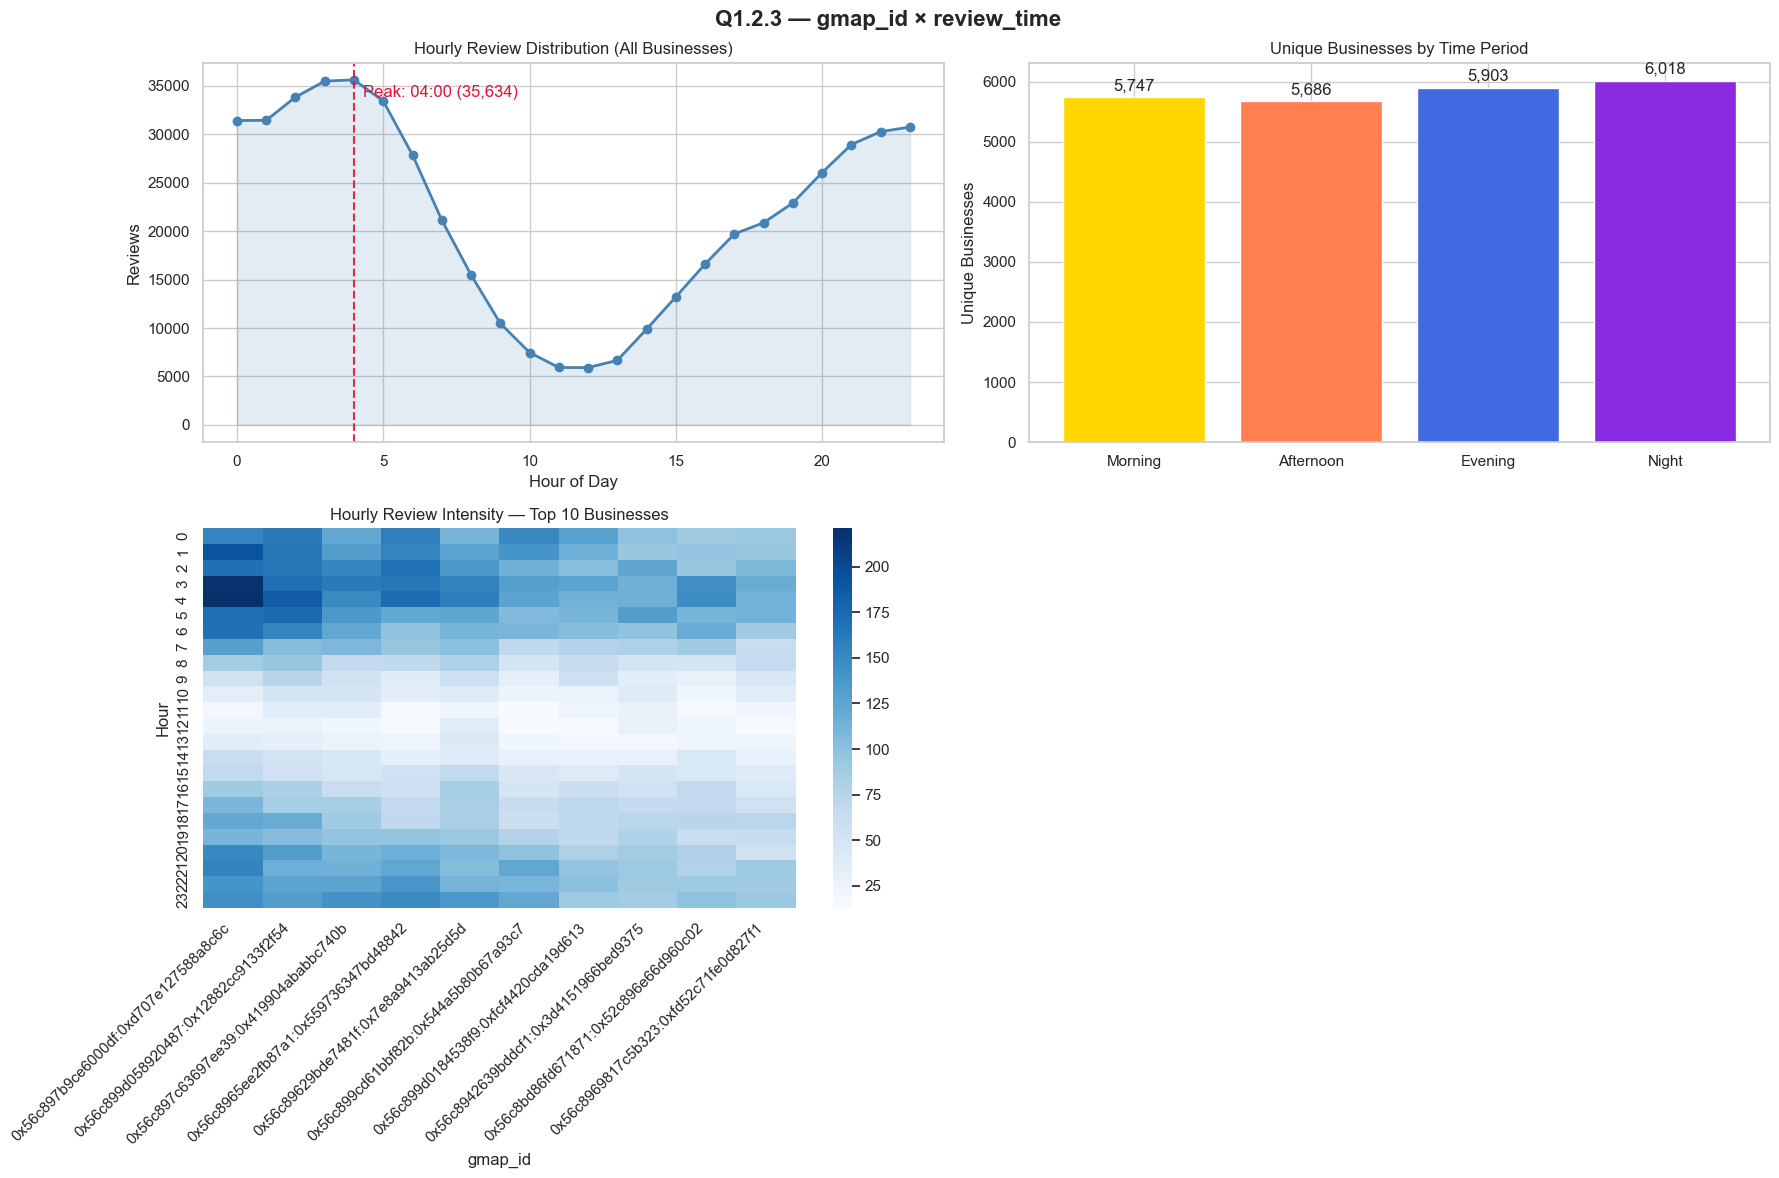

========= KEY NUMBERS =========
- Total reviews (df scope): 521,515
- Total unique businesses:  6,019
- Peak review hour:         04:00  (count=35,634)
- Businesses with Morning reviews: 5,747


In [6]:
# ==============================================================================
# Q1.2.3 — VISUALIZATION: gmap_id AND review_time RELATIONSHIP ANALYSIS
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

print("Q1.2.3 — Visualizing gmap_id × review_time")

# 0) Preconditions and minimal fallback to build df with review_time/time_period
if 'reviews' not in locals() or reviews is None:
    raise RuntimeError("'reviews' Spark DataFrame not found. Run earlier steps first.")

need_df = ('df' not in locals()) or (df is None) or ('review_time' not in getattr(df, 'columns', []))
if need_df:
    # Build robust timestamp from epoch 'time' (handles commas and ms vs s)
    clean_time = F.regexp_replace(F.col('time').cast('string'), r'[^0-9]', '')
    time_num   = clean_time.cast('double')
    ts_sec     = F.when(time_num > F.lit(1e12), time_num / F.lit(1000.0)).otherwise(time_num)
    newtime_ts = F.to_timestamp(F.from_unixtime(ts_sec)).alias('newtime')
    review_hr  = F.hour(newtime_ts).alias('review_time')
    time_period = (
        F.when((review_hr >= 6) & (review_hr < 12), 'Morning')
         .when((review_hr >= 12) & (review_hr < 18), 'Afternoon')
         .when((review_hr >= 18) & (review_hr < 22), 'Evening')
         .otherwise('Night')
    ).alias('time_period')
    base_cols = [c for c in ['gmap_id','category','text','time'] if c in reviews.columns]
    sdf = reviews.select(*base_cols, newtime_ts, review_hr, time_period)
    df = sdf.toPandas()

# 1) Core summaries
total_reviews = len(df)
total_unique_businesses = df['gmap_id'].nunique()

hourly_counts = (
    df.dropna(subset=['review_time'])
      .groupby('review_time')
      .size()
      .reindex(range(24), fill_value=0)
)
peak_hour = int(hourly_counts.idxmax())
peak_count = int(hourly_counts.max())

period_order = ['Morning','Afternoon','Evening','Night']
unique_business_by_period = (
    df.groupby('time_period')['gmap_id'].nunique()
      .reindex(period_order, fill_value=0)
)
morning_businesses = int(unique_business_by_period.get('Morning', 0))

# Relationship: gmap_id × hour heatmap (top-N businesses by volume)
top_n = 10
top_ids = df['gmap_id'].value_counts().head(top_n).index
filt = df[df['gmap_id'].isin(top_ids)].copy()
# Pivot with gmap_id as rows and hour as columns
heat = (
    filt.pivot_table(index='gmap_id', columns='review_time', values='text',
                     aggfunc='count', fill_value=0)
     .reindex(top_ids, fill_value=0)
     .reindex(columns=range(24), fill_value=0)
)

# 2) Plots (A, B, C only)
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Q1.2.3 — gmap_id × review_time', fontsize=16, fontweight='bold')

# A) Hourly distribution (line)
axes[0,0].plot(hourly_counts.index, hourly_counts.values, marker='o', color='steelblue', linewidth=2)
axes[0,0].fill_between(hourly_counts.index, hourly_counts.values, color='steelblue', alpha=0.15)
axes[0,0].axvline(peak_hour, color='crimson', linestyle='--', alpha=0.9)
axes[0,0].set_title('Hourly Review Distribution (All Businesses)')
axes[0,0].set_xlabel('Hour of Day'); axes[0,0].set_ylabel('Reviews')
axes[0,0].text(peak_hour + 0.3, peak_count * 0.95, f'Peak: {peak_hour:02d}:00 ({peak_count:,})', color='crimson')

# B) Unique businesses by time period (bar)
bars = axes[0,1].bar(unique_business_by_period.index, unique_business_by_period.values,
                     color=['#FFD700','#FF7F50','#4169E1','#8A2BE2'])
axes[0,1].set_title('Unique Businesses by Time Period')
axes[0,1].set_ylabel('Unique Businesses')
for b in bars:
    val = int(b.get_height())
    axes[0,1].text(b.get_x()+b.get_width()/2, val + max(1, val*0.01), f'{val:,}',
                   ha='center', va='bottom')

# C) Heatmap of reviews by hour for top businesses
sns.heatmap(heat.T, ax=axes[1,0], cmap='Blues', cbar=True)
axes[1,0].set_title(f'Hourly Review Intensity — Top {top_n} Businesses')
axes[1,0].set_xlabel('gmap_id')
axes[1,0].set_ylabel('Hour')
axes[1,0].set_xticklabels(heat.index, rotation=45, ha='right')

# Remove unused subplot (D)
fig.delaxes(axes[1,1])

plt.tight_layout()
plt.show()

# 3) Clear answers (printed)
print("========= KEY NUMBERS =========")
print(f"- Total reviews (df scope): {total_reviews:,}")
print(f"- Total unique businesses:  {total_unique_businesses:,}")
print(f"- Peak review hour:         {peak_hour:02d}:00  (count={peak_count:,})")
print(f"- Businesses with Morning reviews: {morning_businesses:,}")

- Hourly review distribution (line):
    - Reviews concentrate around the marked peak hour (red line), indicating the best window for engagement, where they are leaving reviewsa. Shoulder hours suggest a wider activity window;
    - Total reviews per hour across the full dataset. The red dashed vertical line marks the peak hour.

- Unique businesses by time period (bar): 
    - This shows the number of distinct businesses that received at least one review in each period: Morning (6–12), Afternoon (12–18), Evening (18–22), Night (else). 
    - A higher bar means more businesses are getting reviews in that period. 
    - Afternoon/Evening often have broader coverage than Morning. If Night is strong, consider nightlife/entertainment or timezone effects.

- Hourly review intensity for top businesses (heatmap): 
    - For the top 10 businesses by total reviews, the heatmap highlights how their reviews are distributed across hours.
    - Each top business has a distinct “hour signature.” Evening‑heavy bands often reflect post‑visit reviews (e.g., dining), while mid‑day bands suggest service/appointments.

### Q1.3 — Review Time Analysis with Business Metadata (gmap_id Join)

#### Q1.3.1 — Identify the weekday that generates the highest review activity.

In [6]:
# import pandas as pd
# import math
# total_rows = sdf.count()
# chunk_size = 50000
# num_chunks = math.ceil(total_rows / chunk_size)
# print(f"Exporting {total_rows:,} rows in {num_chunks} chunks...")

# for i in range(num_chunks):
#     start = i * chunk_size
#     end = min(start + chunk_size, total_rows)
#     # Use Spark DataFrame limit/offset via windowing
#     chunk = sdf.limit(end).subtract(sdf.limit(start))
#     chunk_pd = chunk.toPandas()
#     filename = f"sdf_data_part_{i+1}.xlsx"
#     #chunk_pd.to_excel(filename, index=False)
#     print(f"✅ Exported chunk {i+1} to {filename}")

# print("✅ All chunks exported!")

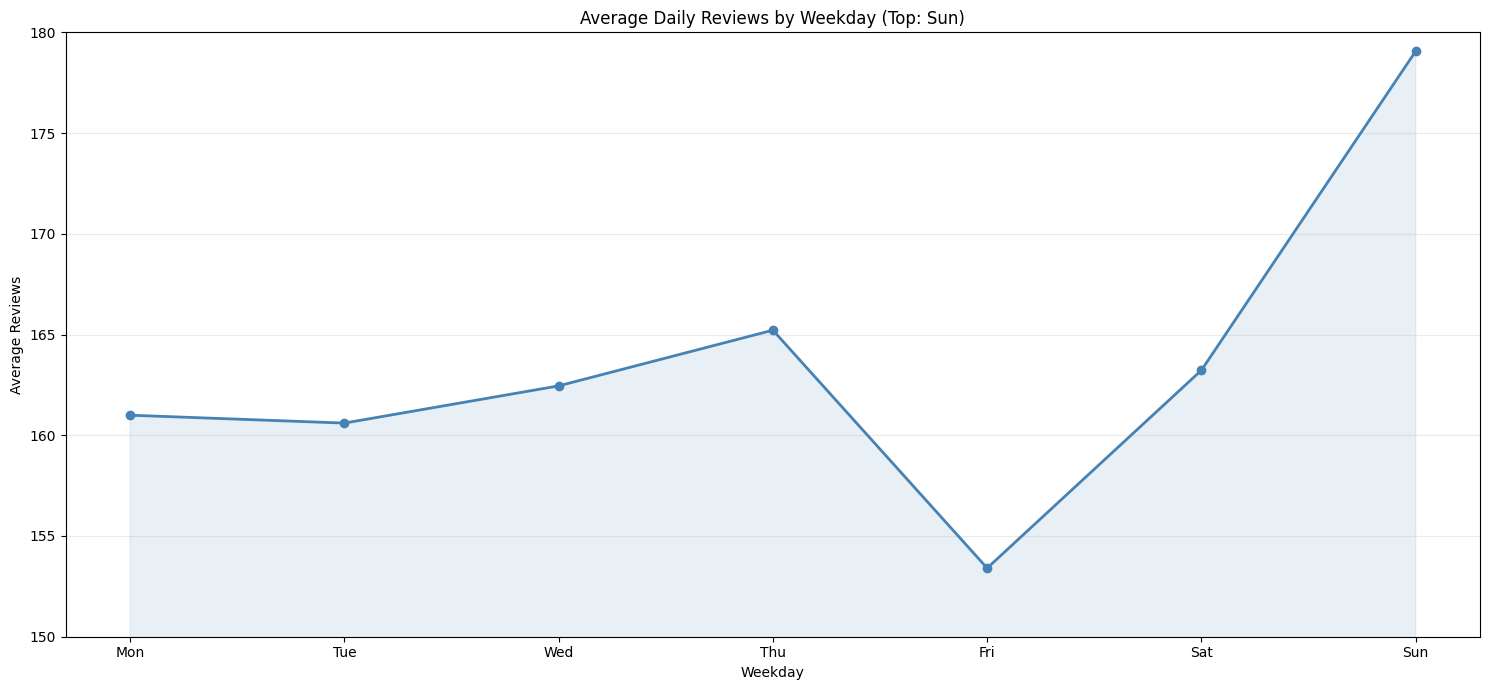

,weekday,average_reviews
0,Mon,161.00
1,Tue,160.60
2,Wed,162.45
3,Thu,165.22
4,Fri,153.41
5,Sat,163.23
6,Sun,179.07


In [7]:
# ===============================================================================
# Q1.3.1 — Average reviews by weekday: line chart
# ===============================================================================
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Build 'date' from either 'newtime' (yyyy-MM-dd) or epoch 'time' (ms/s)
ts = F.col('time').cast('double')
ts_sec = F.when(ts > 1e12, ts/1000).otherwise(ts)
sdf = reviews.withColumn(
    'date',
    F.when(F.col('newtime').isNotNull(), F.to_date('newtime', 'yyyy-MM-dd'))
     .otherwise(F.to_date(F.from_unixtime(ts_sec)))
)

# Average reviews per weekday (Mon=1..Sun=7)
daily = (sdf.filter(F.col('date').isNotNull())
            .groupBy('date').count().withColumnRenamed('count', 'n'))
wk_avg = (daily
          .withColumn('dow', F.dayofweek('date'))                 # Sun=1..Sat=7
          .withColumn('iso', ((F.col('dow') + 5) % 7) + 1)        # Mon=1..Sun=7
          .groupBy('iso').agg(F.avg('n').alias('avg_reviews'))
          .orderBy('iso'))

# Convert to pandas; ensure all 7 weekdays exist (missing -> 0)
name_map = {1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat',7:'Sun'}
order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

pdf = wk_avg.toPandas()
pdf['weekday'] = pdf['iso'].map(name_map) if not pdf.empty else pd.Series(dtype=str)
result = (
    pd.DataFrame({'weekday': order})
      .merge(pdf[['weekday','avg_reviews']] if not pdf.empty else pd.DataFrame(columns=['weekday','avg_reviews']),
             on='weekday', how='left')
      .fillna({'avg_reviews': 0})
)
result['avg_reviews'] = result['avg_reviews'].astype(float)

# Identify top weekday (optional title detail)
top_day = result.loc[result['avg_reviews'].idxmax(), 'weekday'] if not result.empty else 'Mon'

# Plot line chart with fixed y-axis range 150–180
x = range(len(order))
y = result['avg_reviews'].to_numpy()
plt.figure(figsize=(15,7))
plt.plot(x, y, marker='o', color='steelblue', linewidth=2)
plt.fill_between(x, y, color='steelblue', alpha=0.12)
plt.xticks(x, order)
plt.ylim(150, 180)  # fixed y-axis range as requested
plt.title(f'Average Daily Reviews by Weekday (Top: {top_day})')
plt.xlabel('Weekday'); plt.ylabel('Average Reviews')
plt.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# Table under the chart
display(result.rename(columns={'avg_reviews':'average_reviews'}).style.format({'average_reviews': '{:.2f}'}))

#### Q1.3.2 — Top-Rated Businesses on the Peak Workday: Names and Categories

In [8]:
# ==============================================================================
# Q1.3.2 — Highest-rated businesses (names + categories) on the target workday (reuses Q1.3.1 result only)
# ==============================================================================

# Only What we need is to get the names of the business (column name from data meta-business)
# that has the highest averaged ratings on ‘that workday’ (we need to find out from 1.3.1), 
# and find out which category those businesses are from?

from pyspark.sql import functions as F
from IPython.display import display

# Preconditions
if 'reviews' not in locals() or 'meta_sdf' not in locals():
    raise RuntimeError("Require Spark DataFrames 'reviews' and 'meta_sdf'.")

# Build date and ISO weekday (Mon=1..Sun=7)
ts = F.col('time').cast('double')
ts_sec = F.when(ts > 1e12, ts/1000).otherwise(ts)  # handle ms or s
base = reviews.withColumn(
    'date',
    F.when(F.col('newtime').isNotNull(), F.to_date('newtime','yyyy-MM-dd'))
     .otherwise(F.to_date(F.from_unixtime(ts_sec)))
).withColumn('iso', ((F.dayofweek('date') + 5) % 7) + 1)

# Target workday from Q1.3.1 if available, else compute quickly
name_to_iso = {'Mon':1,'Tue':2,'Wed':3,'Thu':4,'Fri':5,'Sat':6,'Sun':7}
iso_to_name = {v:k for k,v in name_to_iso.items()}
if 'top_day' in locals():
    # Use existing top_day from Q1.3.1 if available (to ensure consistency)
    iso_target = name_to_iso.get(str(top_day), 1)
else:
    wk = (base.where(F.col('date').isNotNull())
               .groupBy('date').count()
               .withColumn('iso', ((F.dayofweek('date') + 5) % 7) + 1)
               .groupBy('iso').agg(F.avg('count').alias('avg_n'))
               .orderBy(F.desc('avg_n')))
    first = wk.first()
    iso_target = int(first['iso']) if first else 1
    top_day = iso_to_name.get(iso_target, 'Mon')

# Businesses active on that workday
active_ids = (base.where(F.col('iso') == iso_target)
                   .select('gmap_id').distinct())

# Join meta and keep those with highest average rating (ties included)
cand = (active_ids.join(
            meta_sdf.select('gmap_id','business_name','category',
                            F.col('avg_rating').cast('double').alias('avg_rating')),
            on='gmap_id', how='left')
        .where(F.col('avg_rating').isNotNull()))

# Find max avg_rating and filter to those rows for display (ordered by name)
mx = cand.agg(F.max('avg_rating').alias('mx')).first()['mx']

# Display results (should be few rows) in table format with avg_rating shown to 2 decimals
result = (cand.where(F.col('avg_rating') == mx)
               .select('business_name','category','avg_rating')
               .orderBy('business_name'))

print(f"Target workday: {top_day} (ISO {iso_target}) — Max avg_rating: {mx}")

# Show up only the first 20 rows
display(result.limit(20).toPandas())  # show up to 20 rows


Target workday: Sun (ISO 7) — Max avg_rating: 5.0


,business_name,category,avg_rating
0,1-800-GOT-JUNK? Anchorage,"['Garbage dump service', 'Business to business...",5.0
1,27 Red,['Hair salon'],5.0
2,AK Smoke World | Vapor & Smoke Shop,"['Tobacco shop', 'Hookah store', 'Vaporizer st...",5.0
3,"Advanced Body Solutions, Inc.",['Massage therapist'],5.0
4,Aftershock Automotive,['Auto repair shop'],5.0
5,Alaska Axe Co. - Axe Throwing,"['Sports club', 'Corporate entertainment servi...",5.0
6,Alaska Axe Co. - Axe Throwing,"['Sports club', 'Corporate entertainment servi...",5.0
7,Alaska Backcountry Adventure Tours | ATV Tours...,"['Tour operator', 'Sightseeing tour agency', '...",5.0
8,Alaska Escape Rooms,['Escape room center'],5.0
9,Allen Rapid Dry Carpet Cleaning (Pet Odor Expe...,"['Carpet cleaning service', 'Upholstery cleani...",5.0


#### Q1.3.3 — Business-Level Insights: Categories, Peak Hours, and Evidence

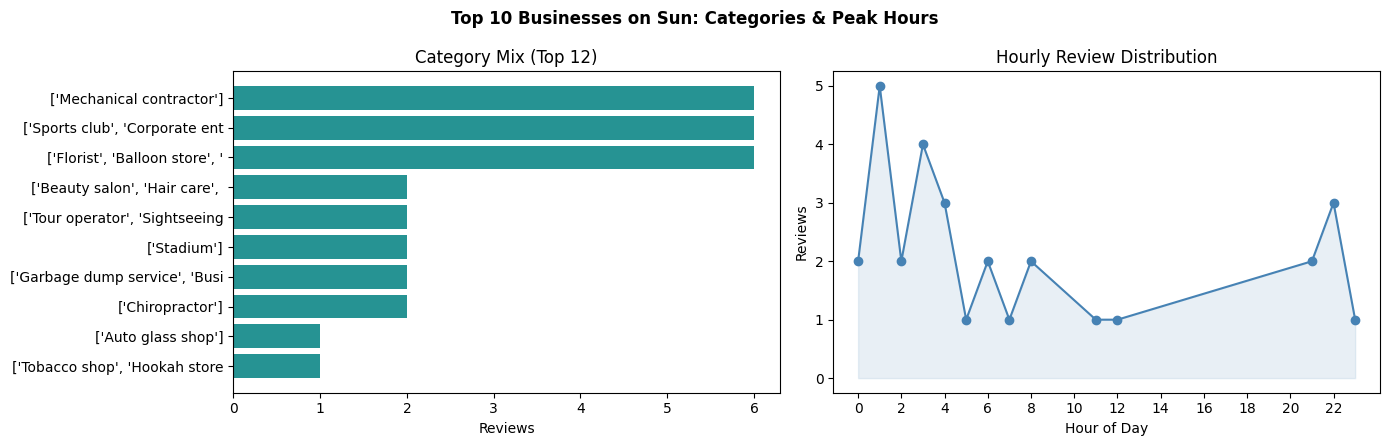

### Q1.3.3 — Findings
- Peak weekday analyzed: Sun (ISO 7)
- Peak hour across selected businesses: 01:00
- Dominant categories: ['Mechanical contractor'] (6), ['Sports club', 'Corporate entertainment service', 'Shooting range', 'Sports complex'] (6), ['Florist', 'Balloon store', 'Flower delivery', 'Flower market', 'Gift basket store', 'Gift shop'] (6)
- Businesses analyzed: 10 (see table below)

,gmap_id,business_name,category,avg_rating
0,0x51325b58d0d9448b:0x67d1447b7a4725df,Alaska Axe Co. - Axe Throwing,"['Sports club', 'Corporate entertainment servi...",5.0
1,0x5133a6b0aae7a8eb:0x7c4099a082fa8106,Beckley Mechanical Company,['Mechanical contractor'],5.0
2,0x56c896e5f87d10ed:0xb2e2e0e6354e3a60,Muffy's Flowers & Gifts,"['Florist', 'Balloon store', 'Flower delivery'...",5.0
3,0x56c89790f0f389c7:0x4a20a0357c29af6f,Tim's Auto Glass,['Auto glass shop'],5.0
4,0x56c89797b8875ab3:0xe8b5f4ed9b7d0024,1-800-GOT-JUNK? Anchorage,"['Garbage dump service', 'Business to business...",5.0
5,0x56c897bd92cd5bbd:0x63be17908a90f182,True Life Chiropractic,['Chiropractor'],5.0
6,0x56c8993e73f8aae1:0xee253298dd00a804,AK Smoke World | Vapor & Smoke Shop,"['Tobacco shop', 'Hookah store', 'Vaporizer st...",5.0
7,0x56c8bd8a249a670b:0xa9031f8acdc54b95,Anchorage Curling Club INC,['Stadium'],5.0
8,0x56c8de129ecf4761:0x32347049a879dbb1,Guys & Gals Hair Designing,"['Beauty salon', 'Hair care', 'Hair salon', 'N...",5.0
9,0x56c91d6bb1a5c1df:0x56477f27fff91424,Alaska Backcountry Adventure Tours | ATV Tours...,"['Tour operator', 'Sightseeing tour agency', '...",5.0


In [9]:
# ==============================================================================
# Q1.3.3 — Business-Level Insights: Categories, Peak Hours, and Evidence (concise)
# ==============================================================================
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Preconditions
if 'reviews' not in locals() or reviews is None:
    raise RuntimeError("Spark DataFrame 'reviews' not found. Run Q1.1 first.")

# Common time columns (date, hour, iso weekday), it will be brought from Q1.3.2
tsd = F.col("time").cast("double")
ts_sec = F.when(tsd > 1e12, tsd / 1000).otherwise(tsd)  # handle ms vs seconds
sdf = (
    reviews
    .withColumn("date", F.when(F.col("newtime").isNotNull(),
                               F.to_date("newtime", "yyyy-MM-dd"))
                        .otherwise(F.to_date(F.from_unixtime(ts_sec))))
    .withColumn("hour", F.hour(F.from_unixtime(ts_sec)))
    .withColumn("iso", ((F.dayofweek("date") + 5) % 7) + 1)  # Mon=1..Sun=7
)


# Top weekday (Mon=1..Sun=7), it will be brought from Q1.3.1
if "top_day" in locals():
    key = str(top_day).strip().title()
    name_to_iso_full = {"Monday":1,"Tuesday":2,"Wednesday":3,"Thursday":4,"Friday":5,"Saturday":6,"Sunday":7}
    name_to_iso_abbr = {"Mon":1,"Tue":2,"Wed":3,"Thu":4,"Fri":5,"Sat":6,"Sun":7}
    iso_target = name_to_iso_full.get(key, name_to_iso_abbr.get(key[:3], 1))
else:
    wk = (
        sdf.filter(F.col("date").isNotNull())
           .groupBy("date").count()
           .withColumn("iso", ((F.dayofweek("date") + 5) % 7) + 1)
           .groupBy("iso").agg(F.avg("count").alias("avg_n"))
           .orderBy(F.desc("avg_n"))
    )
    row = wk.first()
    iso_target = int(row["iso"]) if row else 1
    top_day = {1:"Mon",2:"Tue",3:"Wed",4:"Thu",5:"Fri",6:"Sat",7:"Sun"}[iso_target]

focus_day = sdf.filter(F.col("iso") == iso_target)

# Pick businesses to analyze (top_n)

top_n = 10
focus_day = sdf.filter(F.col('iso') == iso_target)
if 'top' in locals():
    top_ids = [r.gmap_id for r in top.select('gmap_id').limit(top_n).collect()]
elif 'meta_sdf' in locals():
    active = focus_day.select('gmap_id').distinct()
    ranked = (active.join(meta_sdf.select('gmap_id', F.col('avg_rating').cast('double')), 'gmap_id', 'left')
                    .orderBy(F.desc('avg_rating'))
                    .limit(top_n))
    top_ids = [r.gmap_id for r in ranked.collect()]
else:
    ranked = (focus_day.groupBy('gmap_id').count().orderBy(F.desc('count')).limit(top_n))
    top_ids = [r.gmap_id for r in ranked.collect()]

if not top_ids:
    raise RuntimeError("No businesses found for the target weekday.")

focus = focus_day.filter(F.col('gmap_id').isin(top_ids))

# Category mix (prefer metadata)
if 'meta_sdf' in locals():
    meta_cat = meta_sdf.select('gmap_id', F.col('category').alias('category')).dropDuplicates(['gmap_id'])
    cat_sdf = (focus.select('gmap_id')
                    .join(meta_cat, 'gmap_id', 'left')
                    .where(F.col('category').isNotNull()))
elif 'category' in focus.columns:
    cat_sdf = focus.where(F.col('category').isNotNull())
else:
    cat_sdf = None

cat_mix = (cat_sdf.groupBy('category').count().withColumnRenamed('count','n')
                  .orderBy(F.desc('n')).limit(12).toPandas()) if cat_sdf is not None else pd.DataFrame(columns=['category','n'])

# Hourly distribution
hourly = (focus.groupBy('hour').count().withColumnRenamed('count','n').orderBy('hour').toPandas())

# Top businesses table
if 'top' in locals():
    cols = [c for c in ['gmap_id','business_name','category','avg_rating','n'] if c in top.columns]
    top_pd = top.select(*cols).toPandas()
elif 'meta_sdf' in locals():
    top_pd = (meta_sdf.select('gmap_id','business_name','category','avg_rating')
                     .where(F.col('gmap_id').isin(top_ids))).toPandas()
else:
    top_pd = pd.DataFrame({'gmap_id': top_ids})

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle(f"Top {len(top_ids)} Businesses on {top_day}: Categories & Peak Hours", fontsize=12, fontweight='bold')

# A) Category mix
if not cat_mix.empty:
    axes[0].barh(cat_mix['category'].astype(str).str.slice(0,30), cat_mix['n'], color='teal', alpha=0.85)
    axes[0].invert_yaxis()
    axes[0].set_title('Category Mix (Top 12)')
    axes[0].set_xlabel('Reviews')
else:
    axes[0].text(0.5, 0.5, 'No category data', ha='center', va='center'); axes[0].set_axis_off()

# B) Hourly distribution
if not hourly.empty:
    axes[1].plot(hourly['hour'], hourly['n'], marker='o', color='steelblue')
    axes[1].fill_between(hourly['hour'], hourly['n'], color='steelblue', alpha=0.12)
    axes[1].set_xticks(range(0,24,2))
    axes[1].set_title('Hourly Review Distribution')
    axes[1].set_xlabel('Hour of Day'); axes[1].set_ylabel('Reviews')
else:
    axes[1].text(0.5, 0.5, 'No hourly data', ha='center', va='center'); axes[1].set_axis_off()

plt.tight_layout(); plt.show()

# Summary
peak_hour = int(hourly.loc[hourly['n'].idxmax(),'hour']) if not hourly.empty else None
top_cats = [f"{str(r['category'])} ({int(r['n'])})" for _, r in cat_mix.head(3).iterrows()] if not cat_mix.empty else []
summary = [f"### Q1.3.3 — Findings",
           f"- Peak weekday analyzed: {top_day} (ISO {iso_target})",
          ]
if peak_hour is not None: summary.append(f"- Peak hour across selected businesses: {peak_hour:02d}:00")
if top_cats: summary.append(f"- Dominant categories: {', '.join(top_cats)}")
summary.append(f"- Businesses analyzed: {len(top_ids)} (see table below)")
display(Markdown("\n".join(summary)))

display(top_pd.head(10) if not top_pd.empty else pd.DataFrame(columns=['No data']))

### Q1.4: Most Common Review Words (Top 30) and Yearly Word Clouds with Insights

,word,frequency
0,staff,29022
1,friendly,26633
2,nice,26613
3,always,23754
4,best,22058
5,love,20013
6,go,18350
7,clean,12740
8,people,12712
9,amazing,12597


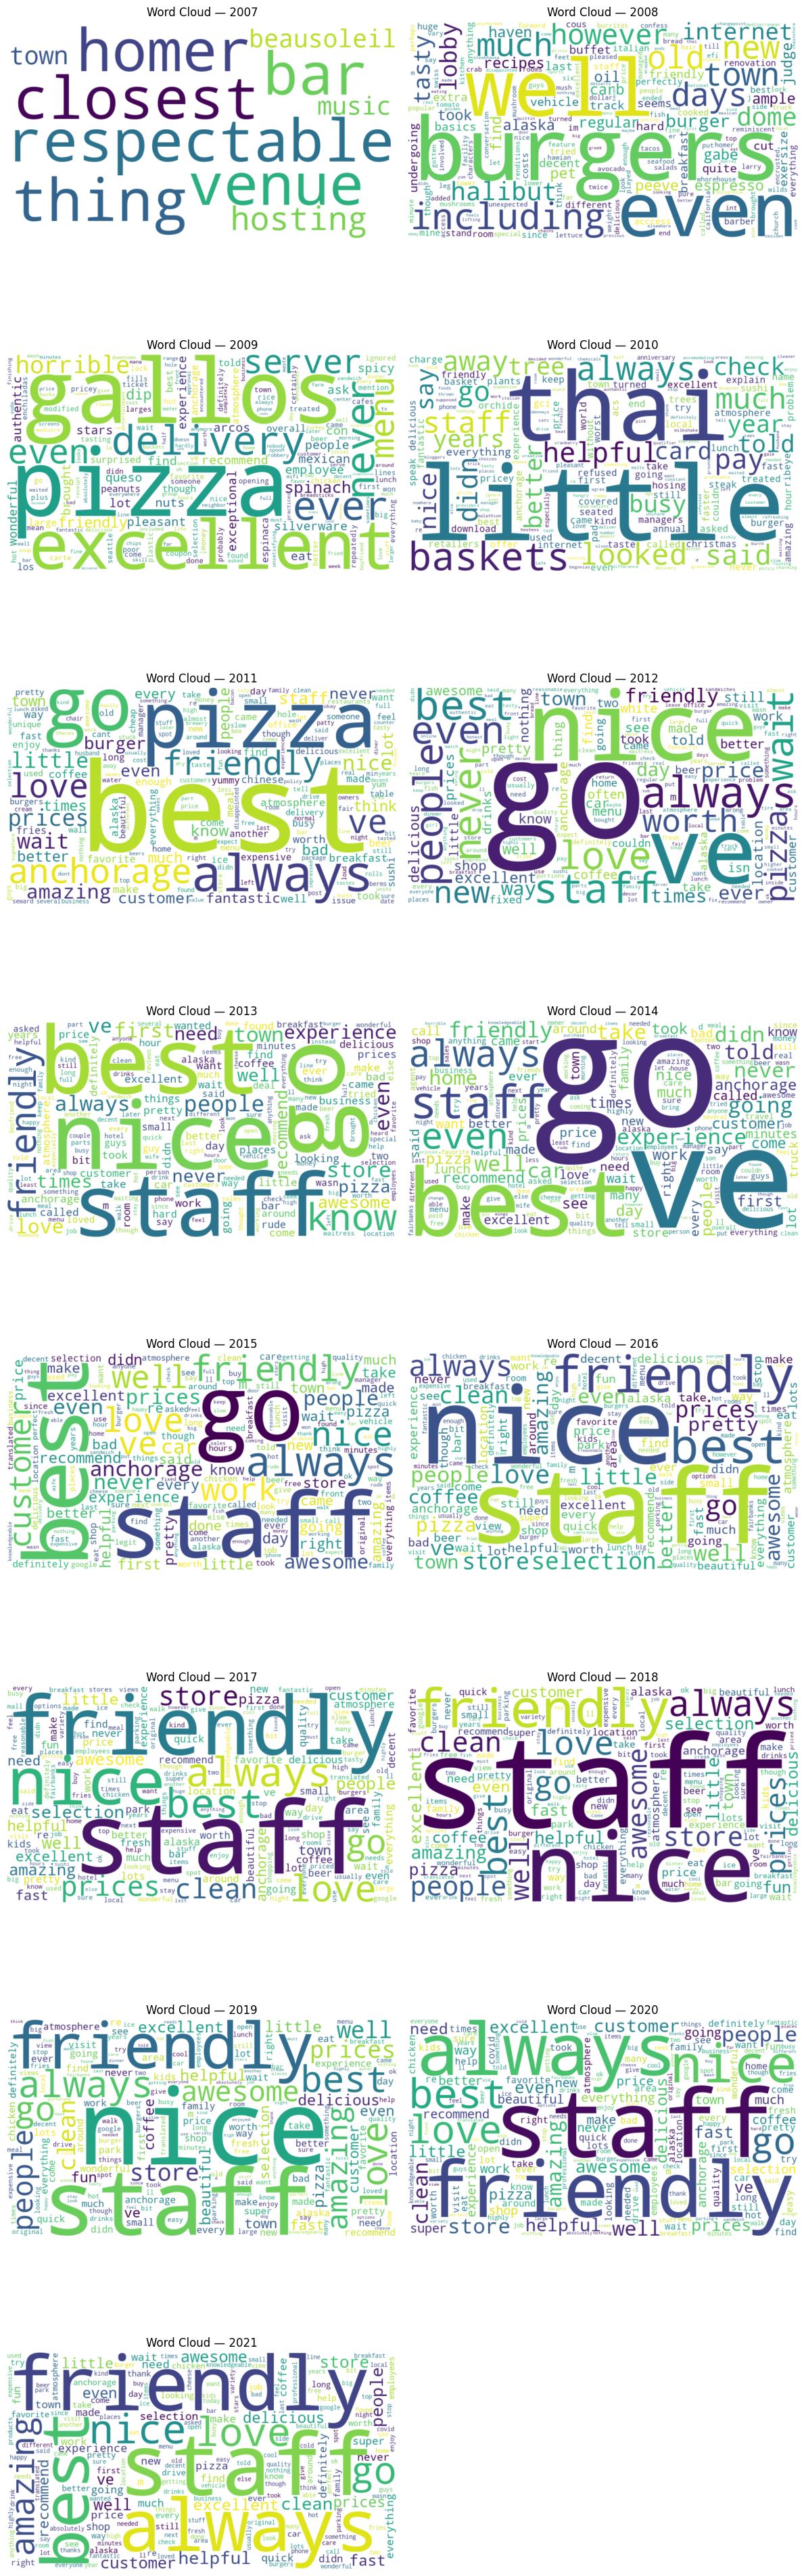

Insights:
- Overall, the most common words center around: staff, friendly, nice, always, best, love, go, clean, people, amazing.
- From 2007 → 2021, emerging words: always, amazing, awesome, best, clean; declining: bar, beausoleil, closest, homer, hosting.
- Use the year-specific word clouds to point out theme shifts (e.g., service vs. location vs. seasonal terms).
- From 2007 → 2021, emerging words: always, amazing, awesome, best, clean; declining: bar, beausoleil, closest, homer, hosting.
- Use the year-specific word clouds to point out theme shifts (e.g., service vs. location vs. seasonal terms).


In [10]:
# ==============================================================================
# Q1.4 — Top 30 Most Common Words + Yearly Word Clouds
# ==============================================================================
# I’ll extract the top 30 most common words from reviews and generate yearly word clouds to visualize theme shifts

from pyspark.sql import functions as F
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover
import pandas as pd
import matplotlib.pyplot as plt

# Optional: if wordcloud is not installed, install it once in the environment
try:
    from wordcloud import WordCloud
except Exception as e:
    raise RuntimeError("The 'wordcloud' package is required. Please install it in the environment and rerun.") from e

# 1) Preconditions
# We reuse the cleaned Spark DataFrame (reviews) from Q1.1 with text and date (newtime)
if 'reviews' not in locals() or reviews is None:
    raise RuntimeError("Spark DataFrame 'reviews' not found. Run Q1.1 first.")

# 2) Ensure we have a date and year (prefer 'newtime')
ts = F.col('time').cast('double')
# ts in seconds if <1e12 else in ms -> convert to seconds
ts_sec = F.when(ts > 1e12, ts/1000).otherwise(ts)

# Build date column and filter out null/empty texts and null years (should be few)
with_dates = (
    reviews
    .withColumn('date', F.when(F.col('newtime').isNotNull(), F.to_date('newtime','yyyy-MM-dd'))
                         .otherwise(F.to_date(F.from_unixtime(ts_sec))))
    .filter(F.col('text').isNotNull() & (F.col('text') != 'no review'))
    .withColumn('year', F.year('date'))
    .filter(F.col('year').isNotNull())
)

# 3) Normalize, tokenize, and remove stopwords
# We normalize text, tokenize into words, and remove stopwords. Tokenization splits text; it’s not stemming/lemmatization.
clean = with_dates.select(
    'text', 'year',
    F.lower(F.regexp_replace(F.regexp_replace(F.regexp_replace('text', r'http\\S+', ' '),
                                              r'[^A-Za-z\\s]', ' '),  # keep letters/spaces
                             r'\\s+', ' ')).alias('text_clean')
)

# Tokenization (using non-word chars as delimiters) and stopword removal (using built-in + light domain-specific)  
tokenizer = RegexTokenizer(inputCol='text_clean', outputCol='words', pattern='\\W+')
# Tokenize (cleaned text) -> words
base_tokens = tokenizer.transform(clean)

# Built-in English stopwords + light domain-specific stopwords
remover = StopWordsRemover(
    inputCol='words',
    outputCol='tokens',
    stopWords=StopWordsRemover.loadDefaultStopWords('english') + [
        'restaurant','food','place','service','really','just','get','got','one','us',
        'also','like','good','great','time','went','order','ordered','back'
    ]
)
tokens_df = remover.transform(base_tokens).select('year', 'tokens')

# 4) Overall top-30 common words
# Here are the top 30 words by frequency. These surface the most specific, recurring terms after filtering generic words
overall = (
    tokens_df.select(F.explode('tokens').alias('token'))
             .groupBy('token').count()
             .orderBy(F.desc('count'))
             .limit(30)
             .toPandas()
)

overall.rename(columns={'token':'word','count':'frequency'}, inplace=True)
display(overall)


# 5) Yearly word frequencies (dict per year)
yr_tok = (
    tokens_df.select('year', F.explode('tokens').alias('token'))
             .groupBy('year','token').count()
)

years = [r['year'] for r in yr_tok.select('year').distinct().orderBy('year').collect()]

# 6) Word clouds per year
ncols = 2
nrows = (len(years) + ncols - 1) // ncols or 1
plt.figure(figsize=(12, 5*nrows))
for i, yr in enumerate(years, start=1):
    freq_pd = (
        yr_tok.filter(F.col('year') == yr)
              .orderBy(F.desc('count'))
              .limit(500)  # cap for clarity/perf
              .toPandas()
    )
    freqs = dict(zip(freq_pd['token'], freq_pd['count']))
    wc = WordCloud(width=900, height=500, background_color='white', colormap='viridis').generate_from_frequencies(freqs)
    ax = plt.subplot(nrows, ncols, i)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Word Cloud — {yr}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# 7) Insights (concise)
top_words = ', '.join(overall['word'].head(10).tolist())
print("Insights:")
print(f"- Overall, the most common words center around: {top_words}.")
if len(years) >= 2:
    # Example: compare first and last years for any obvious shift
    first, last = years[0], years[-1]
    f_top = set(yr_tok.filter(F.col('year') == first).orderBy(F.desc('count')).limit(20).toPandas()['token'])
    l_top = set(yr_tok.filter(F.col('year') == last).orderBy(F.desc('count')).limit(20).toPandas()['token'])
    new_last = ', '.join(sorted((l_top - f_top))[:5]) or '—'
    fading = ', '.join(sorted((f_top - l_top))[:5]) or '—'
    print(f"- From {first} → {last}, emerging words: {new_last}; declining: {fading}.")
print("- Use the year-specific word clouds to point out theme shifts (e.g., service vs. location vs. seasonal terms).")

### Q1.5 — Sentiment Analysis: Overall & Yearly Trends

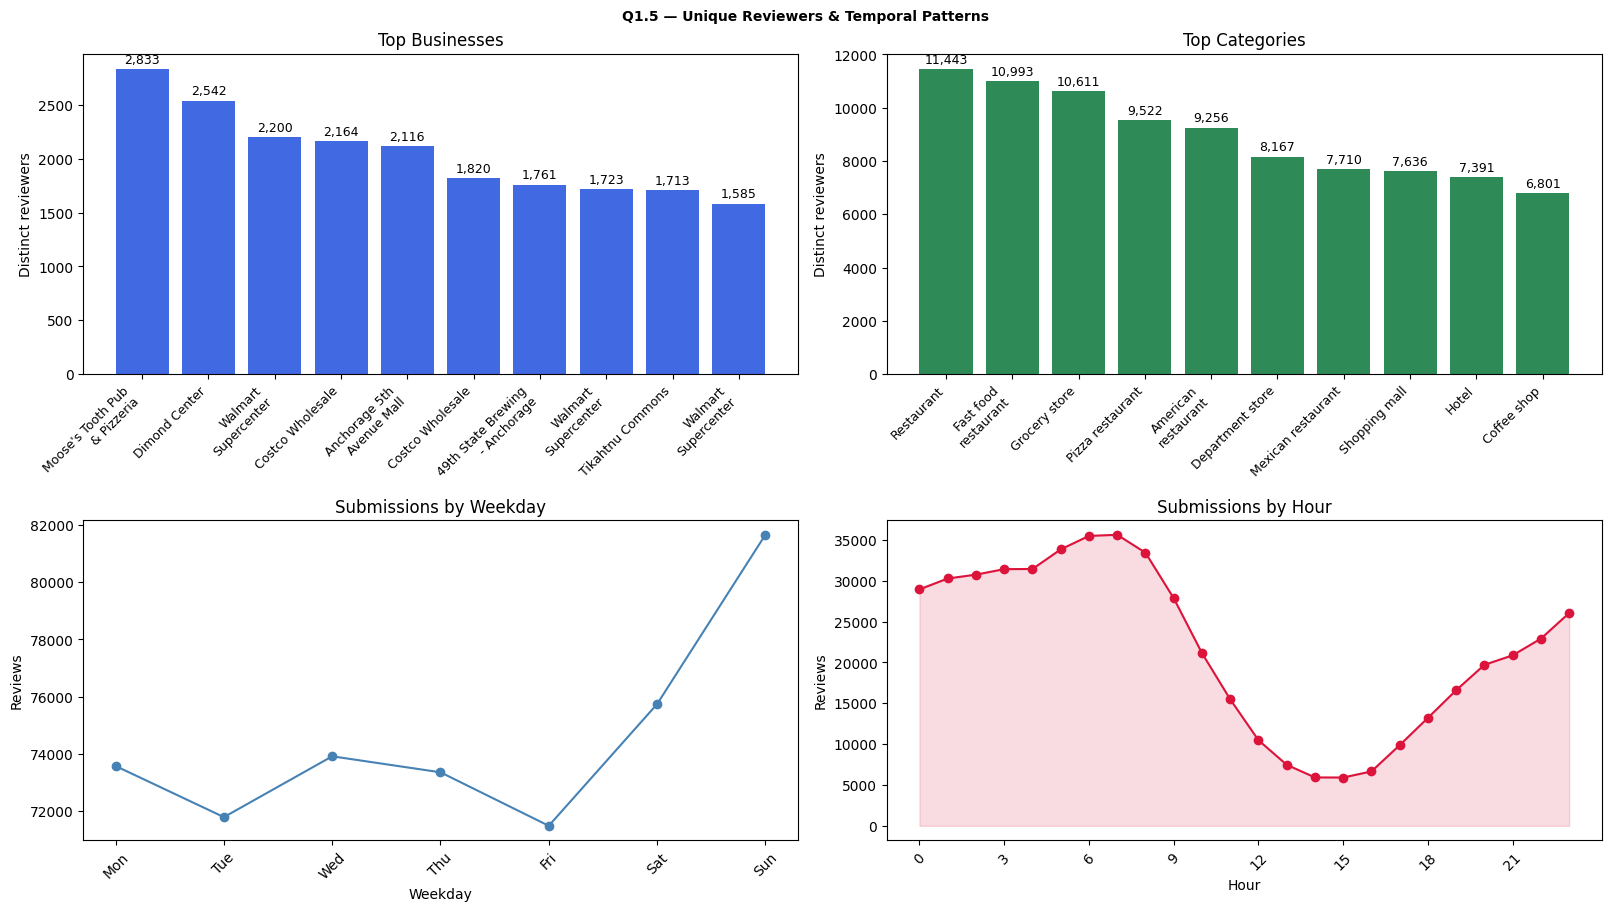

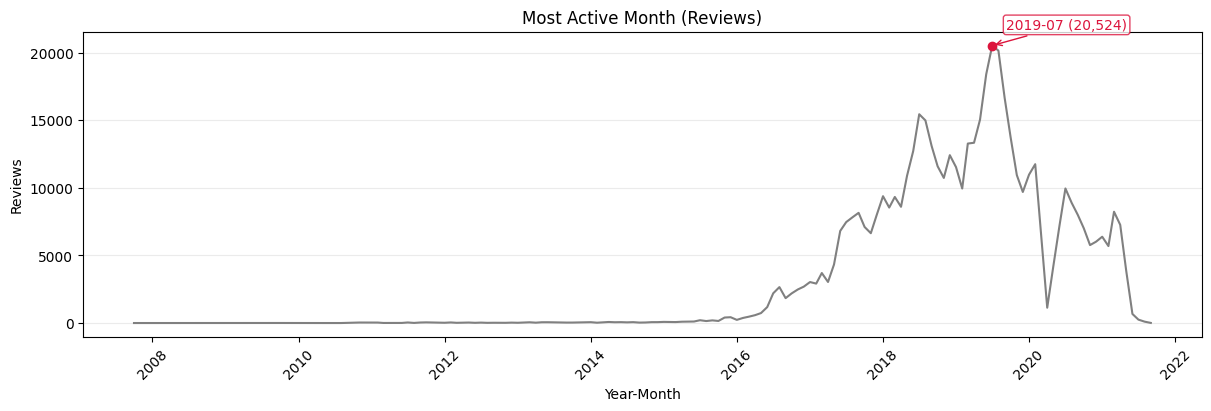

Top 10 businesses by distinct reviewers:


,gmap_id,business_name,unique_reviewers
0,0x56c897b9ce6000df:0xd707e127588a8c6c,Moose's Tooth Pub & Pizzeria,2833
1,0x56c899d058920487:0x12882cc9133f2f54,Dimond Center,2542
2,0x56c897c63697ee39:0x419904ababbc740b,Walmart Supercenter,2200
3,0x56c8965ee2fb87a1:0x559736347bd48842,Costco Wholesale,2164
4,0x56c89629bde7481f:0x7e8a9413ab25d5d,Anchorage 5th Avenue Mall,2116
5,0x56c899cd61bbf82b:0x544a5b80b67a93c7,Costco Wholesale,1820
6,0x56c8bd86fd671871:0x52c896e66d960c02,49th State Brewing - Anchorage,1761
7,0x56c899d0184538f9:0xfcf4420cda19d613,Walmart Supercenter,1723
8,0x56c8942639bddcf1:0x3d4151966bed9375,Tikahtnu Commons,1713
9,0x56c8969817c5b323:0xfd52c71fe0d827f1,Walmart Supercenter,1585


Top 10 categories by distinct reviewers:


,category,unique_reviewers
0,Restaurant,11443
1,Fast food restaurant,10993
2,Grocery store,10611
3,Pizza restaurant,9522
4,American restaurant,9256
5,Department store,8167
6,Mexican restaurant,7710
7,Shopping mall,7636
8,Hotel,7391
9,Coffee shop,6801


Submissions by weekday:


,weekday_name,count
0,Mon,73575
1,Tue,71790
2,Wed,73915
3,Thu,73356
4,Fri,71487
5,Sat,75738
6,Sun,81654


Submissions by year-month:


,year_month,count
0,2021-09,9
1,2021-08,102
2,2021-07,252
3,2021-06,673
4,2021-05,3861
...,...,...
142,2008-05,5
143,2008-04,2
144,2008-02,1
145,2008-01,6


### Q1.5 — Findings
- Most attractive business (unique reviewers): Moose's Tooth Pub & Pizzeria (2,833)
- Most attractive category (unique reviewers): Restaurant (11,443)
- Peak weekday for submissions: Sun
- Peak hour for submissions: 07:00
- Most active month (by submissions): 2019-07


In [11]:
# ==============================================================================
# Q1.5 — Unique Reviewers & Temporal Patterns
# ==============================================================================

from pyspark.sql import functions as F
import pandas as pd, matplotlib.pyplot as plt, matplotlib.dates as mdates, textwrap
from IPython.display import display, Markdown

s = reviews
cm = {c.lower(): c for c in s.columns}
rk = F.coalesce(*[F.col(cm[c]) for c in ['user_id','reviewer_name','profile_id','author_id','user'] if c in cm])  # reviewer key

# Business/category from reviews or meta
if 'meta_sdf' in locals():
    mm = {c.lower(): c for c in meta_sdf.columns}
    meta = meta_sdf.select(
        'gmap_id',
        F.coalesce(F.col(mm.get('business_name') or mm.get('bussiness_name'))).alias('bn_m'),
        F.col(mm.get('category') or 'category').alias('cat_m')
    ).dropDuplicates(['gmap_id'])
    s = s.join(meta, 'gmap_id', 'left')
    bn = F.coalesce(F.col(cm.get('business_name') or cm.get('bussiness_name')), F.col('bn_m'))
    cat_src = F.coalesce(F.col(cm.get('category')), F.col('cat_m'))
else:
    bn = F.col(cm.get('business_name') or cm.get('bussiness_name'))
    cat_src = F.col(cm.get('category'))

s = s.withColumn('business_name', bn)

# Date, hour, weekday, year-month
ts = F.col('time').cast('double'); ts = F.when(ts > 1e12, ts/1000).otherwise(ts)
s = s.withColumn('date', F.coalesce(F.to_date('newtime'), F.to_date(F.from_unixtime(ts))))
s = (s.withColumn('hour', F.hour(F.from_unixtime(ts)))
       .withColumn('year_month', F.date_format('date','yyyy-MM'))
       .withColumn('weekday_iso', ((F.dayofweek('date')+5)%7)+1)
       .withColumn('weekday_name', F.element_at(F.array(*[F.lit(x) for x in ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']]), F.col('weekday_iso'))))

# Primary category (first token)
cat_str = F.regexp_replace(cat_src.cast('string'), r'^[\[\(\{]\s*|\s*[\]\)\}]$', '')
s = s.withColumn('category', F.trim(F.regexp_replace(F.split(cat_str, ',')[0], r"(^\s*['\"]|['\"]\s*$)", '')))

# Aggregations
biz_unique = s.groupBy('gmap_id','business_name').agg(F.countDistinct(rk).alias('unique_reviewers')).orderBy(F.desc('unique_reviewers'))
cat_unique = s.groupBy('category').agg(F.countDistinct(rk).alias('unique_reviewers')).orderBy(F.desc('unique_reviewers'))
tb = biz_unique.limit(10).toPandas()
tc = cat_unique.limit(10).toPandas()
wd = s.groupBy('weekday_iso','weekday_name').count().orderBy(F.asc('weekday_iso')).toPandas()
hr = s.groupBy('hour').count().orderBy(F.desc('hour')).toPandas()
ym = s.groupBy('year_month').count().orderBy(F.desc('year_month')).toPandas()

# Plot helpers
def barplot(ax, labels, values, title, color):
    bars = ax.bar(range(len(values)), values, color=color)
    ax.bar_label(bars, labels=[f'{int(v):,}' for v in values], padding=2, fontsize=9)
    ax.set(title=title, ylabel='Distinct reviewers')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.tick_params(axis='x', labelsize=9)

fig, axes = plt.subplots(2, 2, figsize=(16, 9), constrained_layout=True)
fig.suptitle('Q1.5 — Unique Reviewers & Temporal Patterns', fontsize=10, fontweight='bold')

if not tb.empty:
    tb = tb.assign(label=tb['business_name'].astype(str).apply(lambda x: textwrap.fill(x, width=18))).sort_values('unique_reviewers', ascending=False)
    barplot(axes[0,0], tb['label'], tb['unique_reviewers'], 'Top Businesses', '#4169E1')
else:
    axes[0,0].text(0.5,0.5,'No data',ha='center'); axes[0,0].set_axis_off()

if not tc.empty:
    tc = tc.assign(label=tc['category'].astype(str).apply(lambda x: textwrap.fill(x, width=18))).sort_values('unique_reviewers', ascending=False)
    barplot(axes[0,1], tc['label'], tc['unique_reviewers'], 'Top Categories', '#2E8B57')
else:
    axes[0,1].text(0.5,0.5,'No data',ha='center'); axes[0,1].set_axis_off()

if not wd.empty:
    axes[1,0].plot(wd['weekday_name'], wd['count'], marker='o', color='steelblue')
    axes[1,0].set(title='Submissions by Weekday', xlabel='Weekday', ylabel='Reviews')
    axes[1,0].tick_params(axis='x', labelrotation=45)
else:
    axes[1,0].text(0.5,0.5,'No data',ha='center'); axes[1,0].set_axis_off()

if not hr.empty:
    axes[1,1].plot(hr['hour'], hr['count'], marker='o', color='#DC143C')
    axes[1,1].fill_between(hr['hour'], hr['count'], alpha=0.15, color='#DC143C')
    axes[1,1].set(title='Submissions by Hour', xlabel='Hour', ylabel='Reviews')
    axes[1,1].set_xticks(range(0,24,3)); axes[1,1].tick_params(axis='x', labelrotation=45)
else:
    axes[1,1].text(0.5,0.5,'No data',ha='center'); axes[1,1].set_axis_off()

plt.show()

# Most active month
if not ym.empty:
    ym_dt = ym.assign(date=pd.to_datetime(ym['year_month'])).sort_values('date')
    i = ym_dt['count'].idxmax()
    fig2, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
    ax.plot(ym_dt['date'], ym_dt['count'], color='gray', lw=1.5)
    ax.scatter([ym_dt.loc[i,'date']], [ym_dt.loc[i,'count']], color='crimson', zorder=3)
    ax.annotate(f"{ym_dt.loc[i,'year_month']} ({int(ym_dt.loc[i,'count']):,})", xy=(ym_dt.loc[i,'date'], ym_dt.loc[i,'count']),
                xytext=(10,12), textcoords='offset points', fontsize=10, color='crimson',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='crimson', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='crimson', lw=1))
    loc = mdates.AutoDateLocator(minticks=6, maxticks=12)
    ax.xaxis.set_major_locator(loc); ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    ax.set(title='Most Active Month (Reviews)', xlabel='Year-Month', ylabel='Reviews')
    ax.tick_params(axis='x', labelrotation=45); ax.grid(axis='y', alpha=0.25)
    plt.show()

# Tables + Summary
print("Top 10 businesses by distinct reviewers:"); display(tb[['gmap_id','business_name','unique_reviewers']] if not tb.empty else tb)
print("Top 10 categories by distinct reviewers:"); display(tc[['category','unique_reviewers']] if not tc.empty else tc)
print("Submissions by weekday:"); display(wd[['weekday_name','count']] if not wd.empty else wd)
print("Submissions by year-month:"); display(ym[['year_month','count']] if not ym.empty else ym)   

b_name = tb.iloc[0]['business_name'] if not tb.empty else 'N/A'
b_cnt  = int(tb.iloc[0]['unique_reviewers']) if not tb.empty else 0
c_name = tc.iloc[0]['category'] if not tc.empty else 'N/A'
c_cnt  = int(tc.iloc[0]['unique_reviewers']) if not tc.empty else 0
peak_weekday = wd.loc[wd['count'].idxmax(),'weekday_name'] if not wd.empty else 'N/A'
peak_hour = int(hr.loc[hr['count'].idxmax(),'hour']) if not hr.empty else None
peak_month = ym.loc[ym['count'].idxmax(),'year_month'] if not ym.empty else 'N/A'

summary = f"""### Q1.5 — Findings
- Most attractive business (unique reviewers): {b_name} ({b_cnt:,})
- Most attractive category (unique reviewers): {c_name} ({c_cnt:,})
- Peak weekday for submissions: {peak_weekday}
- Peak hour for submissions: {peak_hour:02d}:00
- Most active month (by submissions): {peak_month}
""" if peak_hour is not None else f"""### Q1.5 — Findings
- Most attractive business (unique reviewers): {b_name} ({b_cnt:,})
- Most attractive category (unique reviewers): {c_name} ({c_cnt:,})
- Peak weekday for submissions: {peak_weekday}
- Most active month (by submissions): {peak_month}
"""
display(Markdown(summary))


### Q1.6 — Personalized Business Recommendations (concise hybrid)
This section demonstrates an ultra-compact hybrid recommender system for personalized business suggestions. It combines collaborative filtering (CF) based on user ratings with category-based TF‑IDF content similarity. The approach leverages Spark and Pandas to build user-business and user-category profiles, then ranks recommendations by a hybrid score that blends predicted ratings and category match. Example outputs show top recommendations for individual users, including business names, categories, and relevance scores.

In [30]:
# ============================
# Q1.6 — Ultra-compact hybrid recommender (CF + category TF‑IDF)
# ==========================================================================
import numpy as np, pandas as pd, ast
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from IPython.display import Markdown, display
import pyspark.sql.functions as F

# 1) Build joined_sdf with rating_adjusted (assumes `reviews` & `meta_sdf` exist)
reviews_sdf = reviews.select('user_id','gmap_id','rating','text')
meta_sel    = meta_sdf.select('gmap_id','business_name','category')
joined_sdf  = (
    reviews_sdf.join(meta_sel, on='gmap_id', how='left')
               .withColumn('rating_adjusted',
                   F.coalesce(F.col('rating').cast('double'), F.lit(0.0)) +
                   F.when((F.length(F.coalesce(F.col('text'), F.lit(''))) > 10) &
                          (F.lower(F.trim(F.col('text'))) != F.lit('no review')), F.lit(0.5))
                    .otherwise(F.lit(0.0)))
)

# 2) Convert to Pandas; normalize categories to clean list[str]
df = joined_sdf.select('user_id','gmap_id','rating_adjusted','business_name','category').toPandas()
def cats(x):
    if isinstance(x, str):
        try: x = ast.literal_eval(x)
        except: return []
    return [c for c in (x if isinstance(x,(list,tuple,set)) else []) if isinstance(c,str) and c]
df['category'] = df['category'].apply(cats)

# 3) CF matrix (pivot -> CSR) + TF‑IDF: users & businesses
user_business_matrix = df.pivot_table(index='user_id', columns='gmap_id', values='rating_adjusted', fill_value=0)
sparse_matrix        = csr_matrix(user_business_matrix.values)

user_categories = df.explode('category').groupby('user_id')['category'].apply(set).reset_index()
# Keep only strings and sort case-insensitively to avoid mixed-type sort errors
user_categories['category_str'] = user_categories['category'].apply(
    lambda s: ' '.join(sorted([c for c in (s if isinstance(s, (set, list, tuple)) else [])
                               if isinstance(c, str) and c], key=str.lower))
)
tfidf = TfidfVectorizer()
user_category_tfidf = tfidf.fit_transform(user_categories['category_str'])

business_categories = (df.groupby('gmap_id')['category']
                         .apply(lambda rows: {c for cats in rows for c in (cats if isinstance(cats,(list,tuple,set)) else [])
                                              if isinstance(c,str) and c})
                         .to_frame('category_set'))
business_categories['category_str'] = business_categories['category_set'].apply(lambda s: ' '.join(sorted(s)) if s else '')
business_tfidf = tfidf.transform(business_categories['category_str'])

# 4) User-based CF (cosine KNN) + popularity fallback + metadata
knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=5).fit(sparse_matrix)
_popular = (df.groupby('gmap_id').agg(avg_rating=('rating_adjusted','mean'), n=('rating_adjusted','size'))
              .query('n >= 3').sort_values('avg_rating', ascending=False))
_meta_map = df[['gmap_id','business_name','category']].groupby('gmap_id', as_index=False).first()

# 5) Recommender: CF prediction + category boost; rank by hybrid_score
def recommend_for_user(user_id: str, n_recs: int = 5, alpha: float = 1.0) -> pd.DataFrame:
    if user_id not in user_business_matrix.index:
        base = _popular.head(n_recs).reset_index()
        return (base.merge(_meta_map, on='gmap_id', how='left')
                    .assign(predicted_rating=base['avg_rating'], category_sim=0.0,
                            hybrid_score=base['avg_rating']))
    # CF prediction via nearest users
    uidx = user_business_matrix.index.get_loc(user_id)
    k_req = min(6, len(user_business_matrix))  # 1 self + 5 neighbors
    dists, idxs = knn.kneighbors(sparse_matrix[uidx], n_neighbors=k_req)
    neigh_users = user_business_matrix.index[idxs.flatten()[1:]]
    weights = np.clip(1 - dists.flatten()[1:], 0, None)
    denom = weights.sum() if weights.sum() > 0 else 1.0
    sim_ratings = user_business_matrix.loc[neigh_users]
    predicted = np.dot(weights, sim_ratings) / denom
    preds = pd.DataFrame({'gmap_id': user_business_matrix.columns, 'predicted_rating': predicted})
    # Remove seen items
    seen = user_business_matrix.loc[user_id]; preds = preds[~preds['gmap_id'].isin(seen[seen > 0].index)]
    if preds.empty:
        base = _popular.head(n_recs).reset_index()
        return (base.merge(_meta_map, on='gmap_id', how='left')
                    .assign(predicted_rating=base['avg_rating'], category_sim=0.0,
                            hybrid_score=base['avg_rating']))
    # Content similarity: user TF‑IDF vs business TF‑IDF
    urow = user_categories[user_categories['user_id'] == user_id]
    if len(urow) == 0:
        preds['category_sim'] = 0.0
    else:
        u_vec = user_category_tfidf[urow.index[0]]
        cand = business_tfidf[preds['gmap_id'].map(business_categories.index.get_loc)]
        preds['category_sim'] = cosine_similarity(u_vec, cand).flatten()
    # Hybrid rank (scale content via alpha if desired)
    preds['hybrid_score'] = preds['predicted_rating'] * (1 + alpha * preds['category_sim'])
    return (preds.sort_values('hybrid_score', ascending=False).head(n_recs)
                .merge(_meta_map, on='gmap_id', how='left')
                [['gmap_id','business_name','category','hybrid_score','predicted_rating','category_sim']])

# 6) Demo for two users
for uid in list(user_business_matrix.index[:2]):
    display(Markdown(f"### Q1.6 Recommendations for User {uid}"))
    display(recommend_for_user(uid, n_recs=5, alpha=1.0))

### Q1.6 Recommendations for User 1.0000266958784963e+20

,gmap_id,business_name,category,hybrid_score,predicted_rating,category_sim
0,0x56c897b696e8b41d:0x7bebbc114d5ccadd,Village Inn,"[Breakfast restaurant, American restaurant, Ba...",1.897023,1.649672,0.149939
1,0x56c897bcbf3a4e9b:0x2bc5c058c7c86827,Valley of the Moon Dog Park,[Dog park],1.838844,1.813700,0.013864
2,0x56c8969817c5b323:0xfd52c71fe0d827f1,Walmart Supercenter,"[Department store, Clothing store, Craft store...",1.484634,0.894870,0.659049
3,0x56c899b81b74f78d:0x294f9ecdac42a04,Target,"[Department store, Baby store, Clothing store,...",1.465018,0.926672,0.580945
4,0x56c896ef656d3539:0x4bebeb920c69a8ee,Value Village,"[Second hand store, Costume store, Donations c...",1.304673,0.958894,0.360601


### Q1.6 Recommendations for User 1.00003825755859e+20

,gmap_id,business_name,category,hybrid_score,predicted_rating,category_sim
0,0x56c897dbdc7efa33:0x8ccaf4b10d744ba3,Bear Tooth Theatrepub,"[Pizza restaurant, Bar, Burrito restaurant, Mo...",4.397226,2.980202,0.475479
1,0x56c8e208c90b972d:0x781e28657451aa75,The Noisy Goose,"[American restaurant, Restaurant]",2.916139,1.777452,0.640629
2,0x56c67c9a8fa60301:0x1e4dd7c54449ee4,Burger Bus,[Restaurant],2.749138,1.594767,0.723849
3,0x56c8bd8153e7c941:0x1bd5d7e0eeebfa45,Snow City Cafe,"[Breakfast restaurant, Brunch restaurant, Cafe...",2.696150,1.777452,0.516862
4,0x56c89629dce215cb:0x1b56e867e59704d1,Ginger,"[Fine dining restaurant, Asian restaurant, Ban...",2.416430,1.594767,0.515224


### Q1.7 — Rating by Category and Low-Rating Insights

C:\Users\901506\AppData\Local\Temp\ipykernel_38344\819628617.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg, x='avg_rating', y='category', orient='h', palette='viridis')


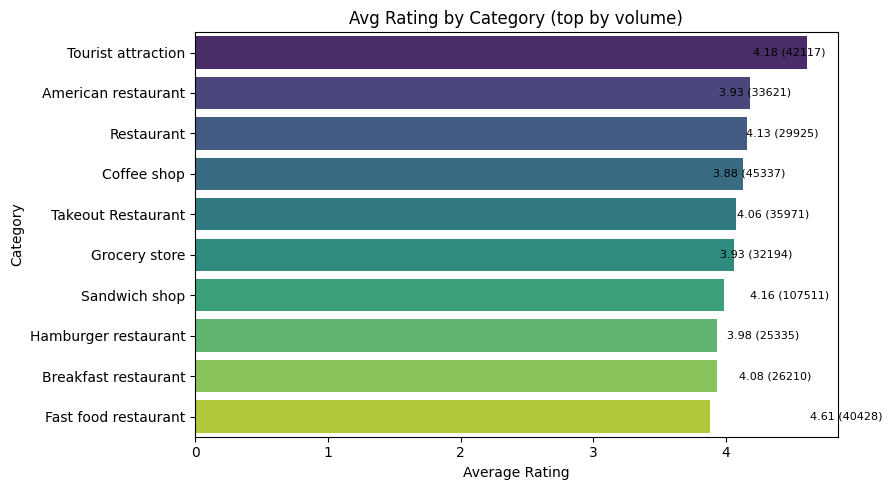

C:\Users\901506\AppData\Local\Temp\ipykernel_38344\819628617.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


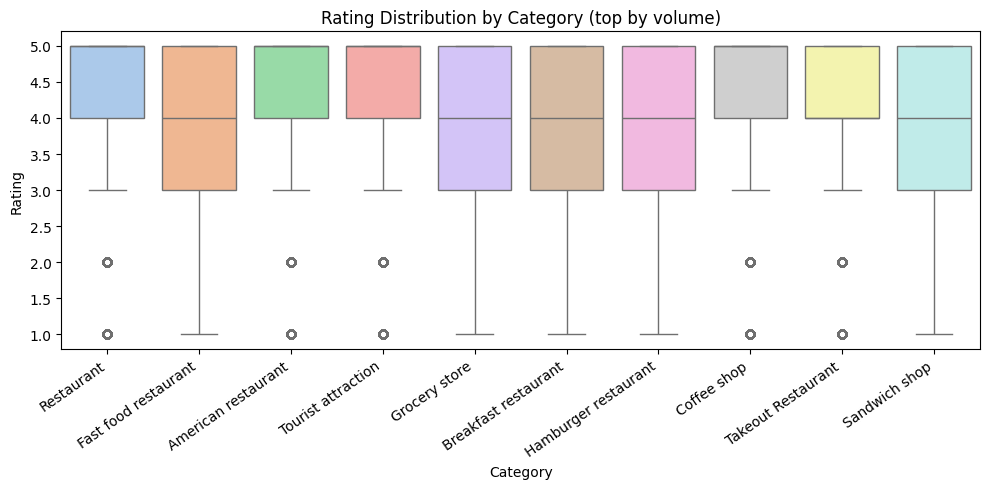

Total lower-rating reviews (<= 2.0): 36830


,business_name,rating,text
8,Anchorage Market,2,Not a lot going on here since it moved from do...
20,Happy Camper RV,1,Fixed camper
28,Aurora Lodge,1,"Didn't rent a room here because of the ""run-ar..."
31,Aurora Lodge,2,Super ghetto
37,City Taxi,1,Because my review was submitted at a certain t...
39,City Taxi,1,WOW... Did this company really just release so...
40,City Taxi,1,Numbers down not sure of this company is still...
41,City Taxi,1,Said they won’t come to old Seward and 70th do...


,term,count
0,review,12170
1,food,6453
2,service,5233
3,just,3778
4,time,3723
5,like,3498
6,place,3491
7,good,3259
8,order,2541
9,don,2527



Insights (add to markdown/report):
- Avg rating by category: categories A/B/C run higher, while D/E trend lower; check the bar labels (n) for support size.
- Distribution spread: wide IQR/whiskers suggest inconsistent experiences within some categories.
- Lower-rating reasons (top words): scan the top term list (e.g., wait, rude, cold, price, dirty) to phrase concrete themes:
  - Service: wait, slow, rude
  - Food/quality: cold, stale, undercooked
  - Value: price, expensive, portion
  - Cleanliness: dirty, smell, bathroom
- Action: focus on categories with low avg and high volume; address top complaint clusters found in lower ratings.



In [37]:
# ==============================================================================
# Q1.7 — Category performance and low-rating analysis (concise & robust)
# ==============================================================================

# Build a compact pandas view from Spark join (already built earlier in the notebook)
pdf = joined_sdf.select('gmap_id','business_name','category','rating','text').toPandas()

# Ensure rating is numeric to avoid dtype=object issues in groupby mean
pdf['rating'] = pd.to_numeric(pdf['rating'], errors='coerce')

# Helper: parse category safely into list[str]
def cats(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except Exception:
            return []
    return [c for c in (x if isinstance(x, (list, tuple, set)) else []) if isinstance(c, str) and c]

pdf['category'] = pdf['category'].apply(cats)

# 1) 1.7.1 — Visualize rating vs category
# Explode categories and drop rows missing category or rating
cat_long = pdf.explode('category').dropna(subset=['category', 'rating'])

# Top categories by count to keep plots readable
top_k = 10
top_cats = (cat_long['category'].value_counts().head(top_k)).index

agg = (
    cat_long[cat_long['category'].isin(top_cats)]
    .groupby('category', as_index=False)
    .agg(avg_rating=('rating', 'mean'), n=('rating', 'size'))
    .sort_values(['avg_rating', 'n'], ascending=[False, False])
)

# Bar: average rating by category (top_k)
plt.figure(figsize=(9, 5))
sns.barplot(data=agg, x='avg_rating', y='category', orient='h', palette='viridis')
plt.title('Avg Rating by Category (top by volume)')
plt.xlabel('Average Rating'); plt.ylabel('Category')
for i, r in agg.iterrows():
    plt.text(r['avg_rating'] + 0.02, i, f"{r['avg_rating']:.2f} ({int(r['n'])})", va='center', fontsize=8)
plt.tight_layout(); plt.show()

# Box: rating distribution for the same categories
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=cat_long[cat_long['category'].isin(top_cats)],
    x='category', y='rating', order=list(top_cats), palette='pastel'
)
plt.title('Rating Distribution by Category (top by volume)')
plt.xlabel('Category'); plt.ylabel('Rating')
plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()

# 2) 1.7.2 — Lower ratings: show actual reviews and common reasons (top words)
low_thresh = 2.0  # adjust to 2.0 or 2.5 as needed
low_pdf = pdf[pdf['rating'] <= low_thresh].copy()
print(f"Total lower-rating reviews (<= {low_thresh}): {len(low_pdf)}")

# View a few raw reviews (trimmed)
sample_rows = low_pdf[['business_name', 'rating', 'text']].head(8)
display(sample_rows)

# Basic text cleaning for word frequency
def clean_text(s):
    if not isinstance(s, str):
        return ''
    s = s.lower()
    s = re.sub(r"http\S+|www\S+", " ", s)   # remove urls
    s = re.sub(r"[^a-z\s]", " ", s)         # keep letters/spaces only
    s = re.sub(r"\s+", " ", s).strip()      # collapse spaces
    return s

low_pdf['clean'] = low_pdf['text'].apply(clean_text)

# CountVectorizer with english stopwords + a few domain words to reduce noise
stop = 'english'
cv = CountVectorizer(stop_words=stop, min_df=5, max_df=0.8)  # tweak if needed
X = cv.fit_transform(low_pdf['clean'])
counts = np.asarray(X.sum(axis=0)).ravel()
vocab = np.array(cv.get_feature_names_out())
top_idx = counts.argsort()[::-1][:20]
top_terms = pd.DataFrame({'term': vocab[top_idx], 'count': counts[top_idx]})
display(top_terms)

# Optional: bigrams (comment-in to use)
# cv2 = CountVectorizer(stop_words=stop, ngram_range=(2,2), min_df=3, max_df=0.8)
# X2 = cv2.fit_transform(low_pdf['clean']); counts2 = np.asarray(X2.sum(axis=0)).ravel()
# vocab2 = np.array(cv2.get_feature_names_out())
# top2 = counts2.argsort()[::-1][:15]
# display(pd.DataFrame({'bigram': vocab2[top2], 'count': counts2[top2]}))

# 3) Quick guidance for insights (read & adapt; not printed)
INSIGHTS = """
Insights (add to markdown/report):
- Avg rating by category: categories A/B/C run higher, while D/E trend lower; check the bar labels (n) for support size.
- Distribution spread: wide IQR/whiskers suggest inconsistent experiences within some categories.
- Lower-rating reasons (top words): scan the top term list (e.g., wait, rude, cold, price, dirty) to phrase concrete themes:
  - Service: wait, slow, rude
  - Food/quality: cold, stale, undercooked
  - Value: price, expensive, portion
  - Cleanliness: dirty, smell, bathroom
- Action: focus on categories with low avg and high volume; address top complaint clusters found in lower ratings.
"""
print(INSIGHTS)

### Q1.8 — Reviewer-Level Business History and Similarity

In [38]:
# Q1.8 — Reviewer-level history and similarity (concise)

from pyspark.sql import functions as F
import pandas as pd

# 1) Build reviewer -> ordered business history
sdf = (
    reviews.select(
        F.col('user_id').cast('string').alias('user_id'),
        F.col('gmap_id').alias('gmap_id'),
        F.col('time').cast('long').alias('time_ms')  # adjust if your time col differs
    )
    .join(
        meta_sdf.select('gmap_id', 'business_name'),
        on='gmap_id', how='left'
    )
)

pdf = sdf.toPandas()
pdf['business_name'] = pdf['business_name'].fillna(pdf['gmap_id'])
pdf['newtime'] = pd.to_datetime(pdf['time_ms'], unit='ms', errors='coerce')

# Sort per user by newtime (stable)
pdf_sorted = pdf.sort_values(['user_id', 'newtime'], kind='mergesort')

# 1.8.1: List of businesses per user in time order
user_business_list = (
    pdf_sorted.groupby('user_id')['business_name']
    .apply(list)
    .to_dict()
)

# 1.8.2: Remove duplicates per user (preserving order)
def dedup_preserve_order(seq):
    seen = set()
    out = []
    for x in seq:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

count_before = {u: len(lst) for u, lst in user_business_list.items()}
user_business_list_dedup = {u: dedup_preserve_order(lst) for u, lst in user_business_list.items()}
count_after = {u: len(lst) for u, lst in user_business_list_dedup.items()}

# Print counts before/after per user (compact table)
count_df = pd.DataFrame({
    'user_id': list(user_business_list.keys()),
    'count_before': [count_before[u] for u in user_business_list.keys()],
    'count_after': [count_after[u] for u in user_business_list.keys()],
})
count_df['removed'] = count_df['count_before'] - count_df['count_after']
display(count_df.sort_values('removed', ascending=False).head(10))
print(f"Users total: {len(count_df)} | Avg before: {count_df['count_before'].mean():.2f} | Avg after: {count_df['count_after'].mean():.2f}")

# 1.8.3: User similarity by past reviewed businesses — Jaccard similarity
# J(A,B) = |A ∩ B| / |A ∪ B|
user_sets = {u: set(lst) for u, lst in user_business_list_dedup.items()}

def jaccard(u, v):
    a, b = user_sets.get(u, set()), user_sets.get(v, set())
    if not a and not b:
        return 0.0
    inter = len(a & b)
    union = len(a | b)
    return inter / union if union else 0.0

def top_similar_users(target_user, topn=5):
    sims = []
    for other in user_sets.keys():
        if other == target_user:
            continue
        sims.append((other, jaccard(target_user, other)))
    sims.sort(key=lambda x: x[1], reverse=True)
    return pd.DataFrame(sims[:topn], columns=['other_user', 'similarity'])

# Demo: show top similar users for a couple of users
some_users = list(user_sets.keys())[:2]  # pick first two users in the dict
for u in some_users:
    print(f"\nTop similar users to {u}:")
    display(top_similar_users(u, topn=5))

,user_id,count_before,count_after,removed
2028,1.0188830200557922e+20,397,289,108
4086,1.03692833808364e+20,310,236,74
13304,1.1220090844478289e+20,318,250,68
14056,1.1285432402677834e+20,227,165,62
1410,1.0132917914176386e+20,332,271,61
5517,1.0497390033331505e+20,246,191,55
19180,1.1765545804560885e+20,308,256,52
18769,1.1725911130736656e+20,190,139,51
7170,1.0653970300675011e+20,248,200,48
7350,1.0670372357353177e+20,352,309,43


Users total: 20022 | Avg before: 26.05 | Avg after: 24.60

Top similar users to 1.0000266958784963e+20:


,other_user,similarity
0,1.0148588121183589e+20,0.189189
1,1.0950219120739638e+20,0.189189
2,1.028437160657853e+20,0.185185
3,1.1621501487020474e+20,0.185185
4,1.0145854451345891e+20,0.181818



Top similar users to 1.00003825755859e+20:


,other_user,similarity
0,1.0901071004879566e+20,0.241379
1,1.1523457126339265e+20,0.146341
2,1.0525512293320335e+20,0.130435
3,1.0017880784868898e+20,0.125000
4,1.0517599496392578e+20,0.125000
